## Run INSPIRE on the mouse skin sections

In this tutorial, we show INSPIRE’s analysis of the mouse skin sections during tissue repair.

The Visium mouse skin data undergoing wound healing are publicly available at [https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE178758](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE178758).

### Import packages

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import get_cmap

import INSPIRE

import warnings
warnings.filterwarnings("ignore")

### Load data

In [2]:
data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/epithelial_organs/data/skin_pnas_tissue_repair"

adata = sc.read_h5ad(data_dir + "/adata_skin_repair_pod0.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["pod"] = "pod 0"
adata.obs.index = adata.obs.index + "-0"
adata_1 = adata.copy()

adata = sc.read_h5ad(data_dir + "/adata_skin_repair_pod7.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["pod"] = "pod 7"
adata.obs.index = adata.obs.index + "-1"
adata_2 = adata.copy()

adata_st_list = [adata_1, adata_2]

### Data preprocessing

Finding highly variable genes...
shape of adata 0 before quality control:  (949, 32272)
shape of adata 0 after quality control:  (948, 12410)
shape of adata 1 before quality control:  (1671, 32272)
shape of adata 1 after quality control:  (1671, 14358)
Find 3186 shared highly variable genes among datasets.
Concatenate datasets as a full anndata for better visualization...


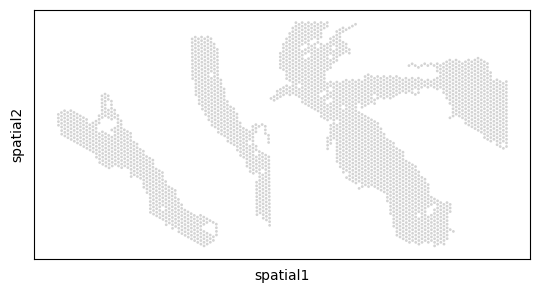

Store counts and library sizes for Poisson modeling...
Normalize data...


In [3]:
adata_st_list, adata_full = INSPIRE.utils.preprocess(adata_st_list=adata_st_list,
                                                     num_hvgs=6000,
                                                     min_genes_qc=20,
                                                     min_cells_qc=20,
                                                     spot_size=100)

### Build spaital graph

In [4]:
adata_st_list = INSPIRE.utils.build_graph_GAT(adata_st_list=adata_st_list,
                                              rad_coef=1.1)

Start building graphs...
Calculate radius cutoff based on 'rad_coef' and mininal distance between spots/cells within a dataset...
Radius for graph connection is 144.1042.
Build graphs for GAT networks
5.2384 neighbors per cell on average.
5.4315 neighbors per cell on average.


### Run INSPIRE model

In [5]:
model = INSPIRE.model.Model_GAT(adata_st_list=adata_st_list,
                                n_spatial_factors=10,
                                n_training_steps=10000,
                                use_margin=False,
                               )

In [6]:
model.train()

  0%|          | 5/10000 [00:00<10:24, 16.01it/s]

Step: 0, d_loss: 1.3595, Loss: 3567.1648, recon_loss: 3394.1226, fe_loss: 71.5511, geom_loss: 188.7298, beta_loss: 96.9005, gan_loss: 0.8160


  5%|▌         | 505/10000 [00:14<04:22, 36.18it/s]

Step: 500, d_loss: 0.5225, Loss: 892.6871, recon_loss: 712.1625, fe_loss: 45.1651, geom_loss: 207.7194, beta_loss: 127.2480, gan_loss: 3.9570


 10%|█         | 1005/10000 [00:27<04:09, 36.12it/s]

...

 90%|█████████ | 9005/10000 [04:10<00:27, 35.89it/s]

Step: 9000, d_loss: 0.0255, Loss: -6617.0732, recon_loss: -6759.8428, fe_loss: 39.0229, geom_loss: 108.3778, beta_loss: 94.3153, gan_loss: 7.2638


 95%|█████████▌| 9505/10000 [04:24<00:13, 35.98it/s]

Step: 9500, d_loss: 0.0184, Loss: -6633.6914, recon_loss: -6776.2329, fe_loss: 38.8920, geom_loss: 107.0849, beta_loss: 94.0243, gan_loss: 7.4836


100%|██████████| 10000/10000 [04:37<00:00, 35.97it/s]


### Access spot representations, proportions of spatial factors in spots, and gene loading matrix

In [7]:
adata_full, basis_df, d_score_dict = model.eval(adata_full, eval_d_scores=True)
basis = np.array(basis_df.values)

Add cell/spot proportions of spatial factors into adata_full.obs...
Add cell/spot latent representations into adata_full.obsm['latent']...
Evaluate discriminator scores...


Gene loading matrix is saved as basis.

### Spatial distributions of spatial factors in tissues

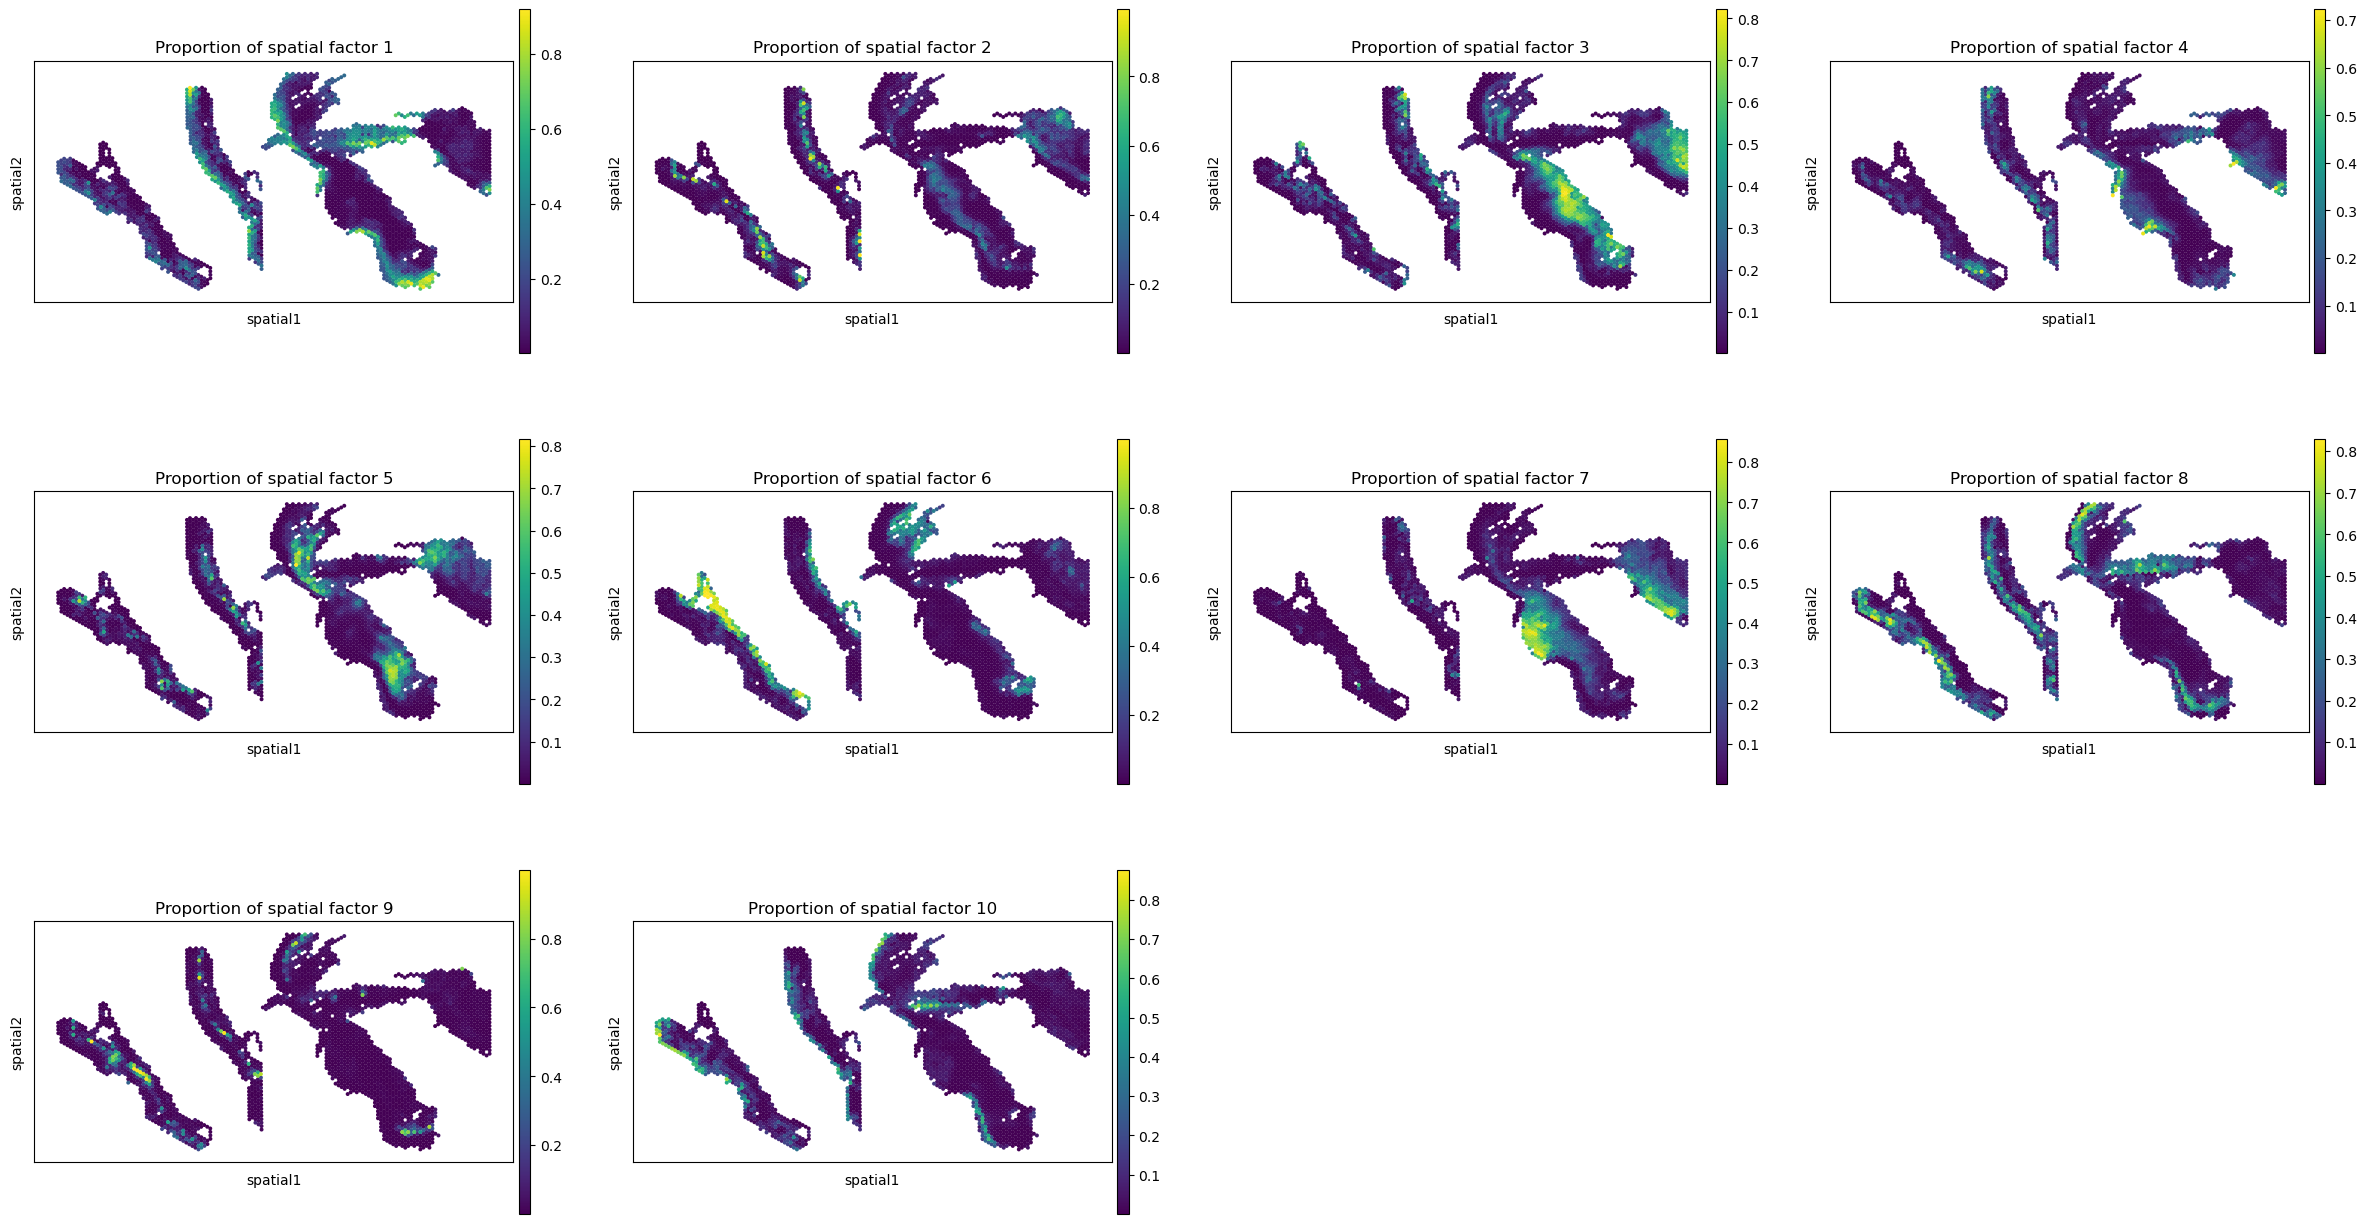

In [8]:
sc.pl.spatial(adata_full, color=["Proportion of spatial factor "+str(i+1) for i in range(10)], spot_size=150.)

### Spot representations and spatial domain identification

In [9]:
# calculate 2D UMAP coordinate of spots based on INSPIRE's learned spot representations.
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="correlation",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata_full.obsm['latent'])
adata_full.obsm["X_umap"] = embedding
adata_full.obs["slice"] = adata_full.obs["slice"].values.astype(str)

UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Thu May 29 10:38:03 2025 Construct fuzzy simplicial set
Thu May 29 10:38:06 2025 Finding Nearest Neighbors
Thu May 29 10:38:07 2025 Finished Nearest Neighbor Search
Thu May 29 10:38:09 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu May 29 10:38:15 2025 Finished embedding


In [10]:
# clustering
sc.pp.neighbors(adata_full, use_rep="latent", n_neighbors=32)
sc.tl.louvain(adata_full, resolution=0.45)

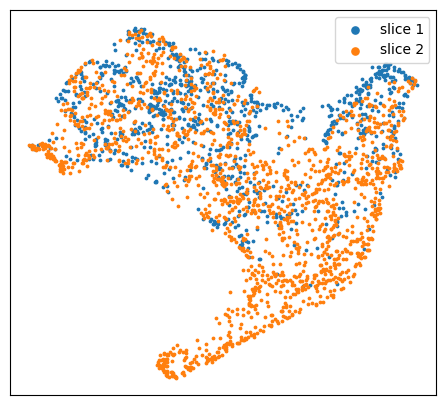

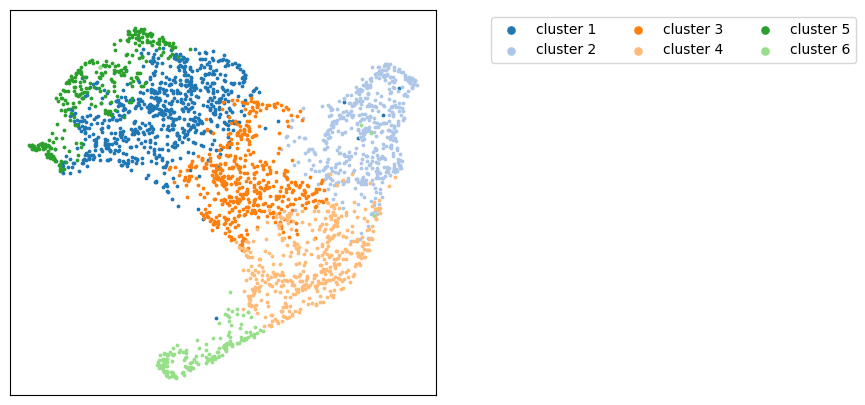

In [11]:
# visualize umaps
size = 3.

rgb_10 = [i for i in get_cmap('Set3').colors]
rgb_20 = [i for i in get_cmap('tab20').colors]
rgb_20b = [i for i in get_cmap('tab20b').colors]
rgb_dark2 = [i for i in get_cmap('Dark2').colors]
rgb_pst1 = [i for i in get_cmap('Pastel1').colors]
rgb_acc = [i for i in get_cmap('Accent').colors]
rgb2hex_10 = [mpl.colors.rgb2hex(color) for color in rgb_10]
rgb2hex_20 = [mpl.colors.rgb2hex(color) for color in rgb_20]
rgb2hex_20b = [mpl.colors.rgb2hex(color) for color in rgb_20b]
rgb2hex_20b_new = [rgb2hex_20b[i] for i in [0, 3, 4, 7, 8, 11, 12, 15, 16, 19]]
rgb2hex_dark2 = [mpl.colors.rgb2hex(color) for color in rgb_dark2]
rgb2hex_pst1 = [mpl.colors.rgb2hex(color) for color in rgb_pst1]
rgb2hex_acc = [mpl.colors.rgb2hex(color) for color in rgb_acc]
rgb2hex = rgb2hex_20 + rgb2hex_20b_new + rgb2hex_dark2 + rgb2hex_pst1 + rgb2hex_acc
colors = rgb2hex

embedding = adata_full.obsm["X_umap"]

# umap, slice
f = plt.figure(figsize=(5.5,5))
ax = f.add_subplot(1,1,1)
colors = ["tab:blue", "tab:orange","tab:green","tab:purple"]
for i in range(len(set(adata_full.obs["slice"]))):
    ax.scatter(embedding[adata_full.obs["slice"]==str(i), 0], embedding[adata_full.obs["slice"]==str(i), 1],
               s=size, c=colors[i], label="slice "+str(i+1))
ax.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
plt.legend(markerscale=3)
plt.show()

# umap, louvain
f = plt.figure(figsize=(5.5,5))
ax = f.add_subplot(1,1,1)
n_louvain = len(set(adata_full.obs["louvain"]))
colors = rgb2hex
for i in range(n_louvain):
    ax.scatter(embedding[adata_full.obs["louvain"].values.astype(str)==str(i), 0],
               embedding[adata_full.obs["louvain"].values.astype(str)==str(i), 1],
               s=size, c=colors[i], label="cluster "+str(i+1))
ax.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
plt.legend(markerscale=3, ncol=3, bbox_to_anchor=(2,1))
plt.show()

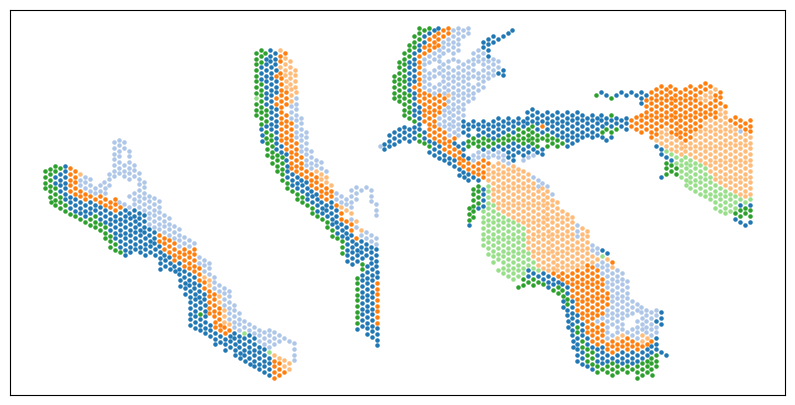

In [12]:
# spatial regions
size = 5.
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(1,1,1)
ax.axis('equal')
colors = rgb2hex
for i in range(n_louvain):
    ax.scatter(adata_full.obsm["spatial"][adata_full.obs["louvain"].values.astype(str)==str(i), 0],
               -adata_full.obsm["spatial"][adata_full.obs["louvain"].values.astype(str)==str(i), 1],
               s=size, c=colors[i], label="cluster "+str(i))
ax.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
plt.show()

### Save results

In [13]:
### Save results
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/mouse_skin_repair"
adata_full.write(res_path + "/adata_inspire_mouse_skin_repair.h5ad")
basis_df.to_csv(res_path + "/basis_df_inspire_mouse_skin_repair.csv")